# Stellar Classification (SDSS17) — a Learning Project

<table><tr>
<td><img src="https://www.nasa.gov/wp-content/uploads/2023/03/650137main_pia15416b-43_full.jpg?w=1024" width="260"><br><center>Galaxy </center></td>
<td><img src="https://science.nasa.gov/wp-content/uploads/2024/10/quasar-banner-illustration.jpg?w=1024" width="260"><br><center>Quasar </center></td>
<td><img src="https://assets.science.nasa.gov/content/dam/science/missions/hubble/releases/1996/12/STScI-01EVTASFNAT35WSB0DW9XR49ZX.jpg/jcr:content/renditions/800x550.jpg" width="260"><br><center>Star (Betelgeuse)</center></td>
</tr></table>

*Credit: NASA/ESA/Hubble. See `README.md` for sources.*

Classifies SDSS17 observations into these three classes — **GALAXY**,
**QUASAR (QSO)**, **STAR** — with a decision tree and a bagging forest
built from first principles (*Grokking Machine Learning* ch. 9: accuracy,
Gini, entropy, information gain, recursive splitting). No scikit-learn.


- **Two packages, one purpose.** `stellar_metta/` holds the "easy" half of
  the math — the three impurity measures and their information gain — as
  plain MeTTa equations, one node at a time. `stellar_python/` holds
  everything that has to be fast (the same math, vectorized with numpy,
  since real tree growth scores thousands of candidate splits per node)
  plus everything built on top of it: the tree, the forest, grid search,
  plotting. `stellar_python/metta_bridge.py` calls the MeTTa files through
  [PeTTa](https://github.com/trueagi-io/PeTTa) so a notebook cell can check
  the two independently-written versions agree. PeTTa itself is not
  bundled here — point `config.json`'s `metta.petta_path` at your local
  PeTTa executable; until then the bridge falls back to the numpy version
  and says so.
- **`DecisionTreeClassifier`**, not `ScratchDecisionTreeClassifier` —
  dropped the prefix everywhere for a plainer read.
- **A fourth stopping criterion.** Trees now stop growing a node when the
  best available split's information gain doesn't clear
  `minInformationGain`, in addition to `maxDepth`, `minSamplesSplit`, and
  `minSamplesLeaf`. Every leaf records *why* it stopped.
- **The forest is optional.** `grid_search.compareTreeVsForest` checks
  whether bagging actually beats a single tuned tree on held-out data;
  if it doesn't, the forest is dropped from the final pipeline rather than
  included on faith.

## A design decision g

The dataset also carries `obj_ID`, `run_ID`, `rerun_ID`, `cam_col`,
`field_ID`, `spec_obj_ID`, `plate`, `MJD`, `fiber_ID`. These record which
SDSS plate/run/fiber captured an object, not a physical property of it —
their per-class means shift systematically because SDSS ran separate
targeting programs per object type. **All nine are dropped.**
Classification uses `alpha`, `delta` (position), `u, g, r, i, z`
(magnitudes), and `redshift` — eight raw columns, nothing synthetic.

## Package layout

| module | role |
|---|---|
| `stellar_metta/spliter.metta` | gini/entropy/accuracy impurity, weighted average — one node, plain MeTTa |
| `stellar_metta/info_gain.metta` | information gain for each of the three, plain MeTTa |
| `stellar_python/impurity_engine.py` | the same formulas, numpy-vectorized for real tree growth |
| `stellar_python/info_gain.py` | vectorized gain, used internally by the split search |
| `stellar_python/decision_nodes.py` | node bookkeeping, vectorized split search, recursive growth, 4 stopping criteria |
| `stellar_python/decision_tree.py` | the public `DecisionTreeClassifier` |
| `stellar_python/tree_plot.py` | text + matplotlib rendering, metrics inside every node |
| `stellar_python/grid_search.py` | hyperparameter search, permutation importance, tree-vs-forest comparison |
| `stellar_python/regularization.py` | `LassoRegression` (ISTA) — the L1 magnitude-collinearity diagnostic |
| `stellar_python/ensemble.py` | `BaggingForest` |
| `stellar_python/preprocessing.py`, `metrics.py`, `persistence.py` | cleaning/splits, metrics (incl. ROC), save/reload |
| `stellar_python/metta_bridge.py` | calls the `.metta` files via PeTTa, with a Python fallback |


## 1. Setup

In [1]:

import json
import sys
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, HTML

sys.path.insert(0, str(Path.cwd()))
from stellar_python import impurity_engine
from stellar_python import decision_nodes
from stellar_python import tree_plot
from stellar_python import grid_search
from stellar_python import metrics
from stellar_python import preprocessing as pp
from stellar_python import persistence
from stellar_python import metta_bridge
from stellar_python.decision_tree import DecisionTreeClassifier
from stellar_python.regularization import LassoRegression
from stellar_python.ensemble import BaggingForest

plt.rcParams["figure.dpi"] = 100
CLASS_COLORS = {"GALAXY": "#4C72B0", "QSO": "#DD8452", "STAR": "#55A868"}

Path("artifacts/tree_plots").mkdir(parents=True, exist_ok=True)
Path("models").mkdir(exist_ok=True)


In [2]:

with open("config.json") as f:
    cfg = json.load(f)
SEED = cfg["seed"]
CLASS_NAMES = cfg["class_names"]
N_CLASSES = len(CLASS_NAMES)
cfg


{'seed': 42,
 'data_path': 'data/star_classification.csv',
 'id_like_columns': ['obj_ID',
  'run_ID',
  'rerun_ID',
  'cam_col',
  'field_ID',
  'spec_obj_ID',
  'plate',
  'MJD',
  'fiber_ID'],
 'magnitude_columns': ['u', 'g', 'r', 'i', 'z'],
 'position_columns': ['alpha', 'delta'],
 'redshift_column': 'redshift',
 'target_column': 'class',
 'class_names': ['GALAXY', 'QSO', 'STAR'],
 'split': {'val_frac': 0.15, 'test_frac': 0.15},
 'sample_size': 20,
 'sample_val_size': 6,
 'hpo_subsample_size': 10000,
 'decorrelation_threshold': 0.9,
 'lasso_diagnostic': {'l1_lambda': 0.02,
  'step_size': 0.3,
  'max_iterations': 400,
  'log_every': 40},
 'top_k_features': 4,
 'min_information_gain_grid': [0.0, 0.001, 0.01],
 'metta': {'petta_dir': 'PeTTa',
  'run_script': 'run.sh',
  'metta_dir': 'stellar_metta',
  'files': ['spliter.metta', 'info_gain.metta'],
  'command_template': ['sh', '{petta_dir}/{run_script}', '{metta_file}'],
  'timeout_seconds': 30,
  'note': "Verified against the real true

## 2. Load and clean data

In [3]:

path_widget = widgets.Text(
    value=cfg["data_path"], description="CSV path:", layout=widgets.Layout(width="500px")
)
display(path_widget)


Text(value='data/star_classification.csv', description='CSV path:', layout=Layout(width='500px'))

In [4]:
df_raw = pd.read_csv(path_widget.value)
mag_cols = cfg["magnitude_columns"]

# ID check: obj_ID and spec_obj_ID should each identify one physical object.
# Average numeric features per ID group -- but only where a "collision" is
# actually the same object (matching sky position within a tight tolerance),
# since a naive groupby-and-average would silently blend together unrelated
# objects if an ID turns out to be reused.
POSITION_TOLERANCE_DEG = 0.001  # ~3.6 arcsec

def averageSameObjectDuplicates(df, idColumn, positionCols, toleranceDeg):
    duplicatedMask = df[idColumn].duplicated(keep=False)
    if not duplicatedMask.any():
        return df, 0, 0, 0

    grouped = df[duplicatedMask].groupby(idColumn)
    positionSpread = grouped[positionCols].apply(lambda g: (g.max() - g.min()).max())
    sameObjectIds = positionSpread[positionSpread < toleranceDeg].index
    recycledIds = positionSpread[positionSpread >= toleranceDeg].index

    numericCols = df.select_dtypes(include=[np.number]).columns.tolist()
    averagedRows = []
    for objId in sameObjectIds:
        group = df[df[idColumn] == objId]
        averaged = group.iloc[0].copy()
        averaged[numericCols] = group[numericCols].mean()
        averagedRows.append(averaged)

    untouchedMask = ~df[idColumn].isin(sameObjectIds)
    result = df[untouchedMask]
    if averagedRows:
        result = pd.concat([result, pd.DataFrame(averagedRows)], ignore_index=True)

    nRecycledGroups = len(recycledIds)
    nRecycledRows = int(grouped.size().loc[recycledIds].sum()) if nRecycledGroups else 0
    return result, len(sameObjectIds), nRecycledGroups, nRecycledRows

n_spec_obj_id_dupes = int(df_raw["spec_obj_ID"].duplicated().sum())
df_raw, n_same_object_averaged, n_recycled_groups, n_recycled_rows = averageSameObjectDuplicates(
    df_raw, "obj_ID", ["alpha", "delta"], POSITION_TOLERANCE_DEG
)
print(f"spec_obj_ID duplicate rows: {n_spec_obj_id_dupes}")
print(f"obj_ID groups that were genuinely the same object (averaged): {n_same_object_averaged}")
print(f"obj_ID groups that were actually different objects sharing a recycled ID "
      f"(left untouched): {n_recycled_groups}  ({n_recycled_rows} rows)")

spec_obj_ID duplicate rows: 0
obj_ID groups that were genuinely the same object (averaged): 8
obj_ID groups that were actually different objects sharing a recycled ID (left untouched): 15351  (37290 rows)


### feature selection



In [5]:
df = pp.dropBadPhotometry(df_raw, mag_cols)
print(f"Loaded {len(df_raw):,} rows, dropped {len(df_raw) - len(df)} sentinel rows, {len(df):,} remain")

class_to_idx = {c: i for i, c in enumerate(CLASS_NAMES)}
y_all = df["class"].map(class_to_idx).to_numpy()

feature_cols = cfg["position_columns"] + mag_cols + [cfg["redshift_column"]]
X_all = df[feature_cols].to_numpy()

print("Feature columns (redshift included directly this time):", feature_cols)
print("Excluded as survey/ID metadata:", cfg["id_like_columns"])

Loaded 99,992 rows, dropped 1 sentinel rows, 99,991 remain
Feature columns (redshift included directly this time): ['alpha', 'delta', 'u', 'g', 'r', 'i', 'z', 'redshift']
Excluded as survey/ID metadata: ['obj_ID', 'run_ID', 'rerun_ID', 'cam_col', 'field_ID', 'spec_obj_ID', 'plate', 'MJD', 'fiber_ID']


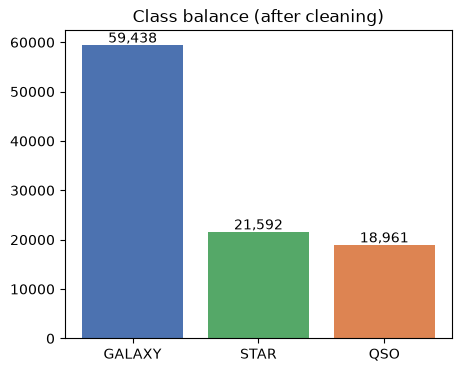

In [6]:

fig, ax = plt.subplots(figsize=(5, 4))
counts = df["class"].value_counts()
ax.bar(counts.index, counts.values, color=[CLASS_COLORS[c] for c in counts.index])
ax.set_title("Class balance (after cleaning)")
for i, v in enumerate(counts.values):
    ax.text(i, v + 500, f"{v:,}", ha="center")
plt.show()


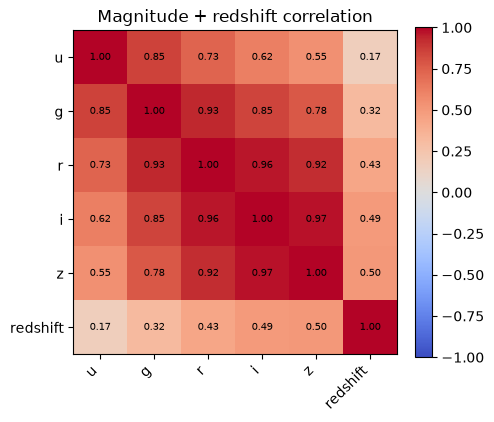

i-z, r-i, g-r all exceed 0.9 — the magnitudes are largely redundant with each other.
Section 4.1 shows what dropping the redundant ones would look like, and why we don't.


In [7]:

corr_cols = mag_cols + [cfg["redshift_column"]]
corr = df[corr_cols].corr()
fig, ax = plt.subplots(figsize=(5, 4.5))
im = ax.imshow(corr, vmin=-1, vmax=1, cmap="coolwarm")
ax.set_xticks(range(len(corr_cols))); ax.set_xticklabels(corr_cols, rotation=45, ha="right")
ax.set_yticks(range(len(corr_cols))); ax.set_yticklabels(corr_cols)
for i in range(len(corr_cols)):
    for j in range(len(corr_cols)):
        ax.text(j, i, f"{corr.iloc[i,j]:.2f}", ha="center", va="center", fontsize=7)
ax.set_title("Magnitude + redshift correlation")
fig.colorbar(im, fraction=0.046)
plt.tight_layout()
plt.show()
print("i-z, r-i, g-r all exceed 0.9 — the magnitudes are largely redundant with each other.")
print("Section 4.1 shows what dropping the redundant ones would look like, and why we don't.")



## 3. Part A — a small worked example

Every step mirrors the book's own progression for its 20-row app dataset,
run here on a stratified sample of the real (cleaned) catalogue.


In [8]:

sample_idx = pp.stratifiedSubsample(y_all, cfg["sample_size"], SEED)
sample_X = X_all[sample_idx]
sample_y = y_all[sample_idx]

sample_table = pd.DataFrame(sample_X, columns=feature_cols)
sample_table["class"] = [CLASS_NAMES[c] for c in sample_y]
sample_table


,alpha,delta,u,g,r,i,z,redshift,class
0,155.701741,17.720254,23.03109,22.64301,20.43675,19.31862,18.78561,0.596466,GALAXY
1,201.397860,36.532331,23.66430,21.97929,21.69781,21.73774,21.56383,-0.000742,STAR
2,233.060181,27.882930,19.12445,17.80301,17.11391,16.69147,16.42012,0.074254,GALAXY
3,22.758164,4.810300,26.35970,22.40104,20.62694,19.56581,19.08042,0.538837,GALAXY
4,244.575313,32.720409,21.89559,22.35476,21.81421,21.71137,21.73997,1.470951,QSO
5,189.437573,47.616328,25.50164,23.04732,21.00084,19.66387,19.46517,0.660438,GALAXY
6,127.975821,11.277385,23.37827,22.02827,20.57274,19.58186,19.39153,0.492420,GALAXY
7,234.765353,31.197953,18.03543,16.48907,15.76653,15.36421,15.10456,0.053960,GALAXY
8,208.982333,4.240550,20.49231,18.61199,17.59223,17.16136,16.79427,0.135986,GALAXY
9,15.444167,0.580801,18.81099,17.68449,17.31192,17.10447,16.95303,0.042004,GALAXY


### 3.1 Impurity of the whole sample, computed two ways

Once with `decision_nodes.py` (numpy), once through `metta_bridge.py` — which runs `stellar_metta/spliter.metta` via PeTTa if it's available, or an equivalent Python fallback otherwise. Same formulas, independent code paths.

In [9]:

sample_counts = np.bincount(sample_y, minlength=N_CLASSES)
c0, c1, c2 = (int(c) for c in sample_counts)
print("class counts:", dict(zip(CLASS_NAMES, sample_counts)))

python_gini = float(impurity_engine.giniImpurity(sample_counts))
python_entropy = float(impurity_engine.entropyImpurity(sample_counts))
python_accuracy = float(impurity_engine.accuracyScore(sample_counts))

metta_gini = metta_bridge.giniImpurity(c0, c1, c2, cfg)
metta_entropy = metta_bridge.entropyImpurity(c0, c1, c2, cfg)
metta_accuracy = metta_bridge.accuracyScore(c0, c1, c2, cfg)

print(f"{'':<10}{'numpy':>10}{'metta':>10}")
print(f"{'gini':<10}{python_gini:>10.4f}{metta_gini:>10.4f}")
print(f"{'entropy':<10}{python_entropy:>10.4f}{metta_entropy:>10.4f}")
print(f"{'accuracy':<10}{python_accuracy:>10.4f}{metta_accuracy:>10.4f}")
assert abs(python_gini - metta_gini) < 1e-9 and abs(python_entropy - metta_entropy) < 1e-9
print("\nnumpy and metta agree.")


class counts: {'GALAXY': np.int64(12), 'QSO': np.int64(4), 'STAR': np.int64(4)}
               numpy     metta
gini          0.5600    0.5600
entropy       1.3710    1.3710
accuracy      0.6000    0.6000

numpy and metta agree.


### 3.2 Best single split, one question, under each criterion

The book's point: accuracy, Gini, and entropy do not always agree on which single feature/threshold is the best first question.

In [10]:

for criterion in ["accuracy", "gini", "entropy"]:
    best = decision_nodes.bestSplitOverall(
        sample_X, sample_y, N_CLASSES, criterion, minSamplesLeaf=1, minInformationGain=0.0,
        featureSubset=np.arange(sample_X.shape[1]),
    )
    if best is None:
        print(f"{criterion:<9}: no valid split")
        continue
    featureIndex, threshold, gain = best
    print(f"{criterion:<9}: split on {feature_cols[featureIndex]:<9} <= {threshold:.4f}   gain={gain:.4f}")


accuracy : split on i         <= 19.9261   gain=0.2000
gini     : split on redshift  <= 0.0209   gain=0.2600
entropy  : split on redshift  <= 0.0209   gain=0.7219


### 3.3 Grow and plot a tree per criterion

accuracy : depth=2  leaves=4  train_acc=1.000


saved artifacts/tree_plots/tree_accuracy_sample.png


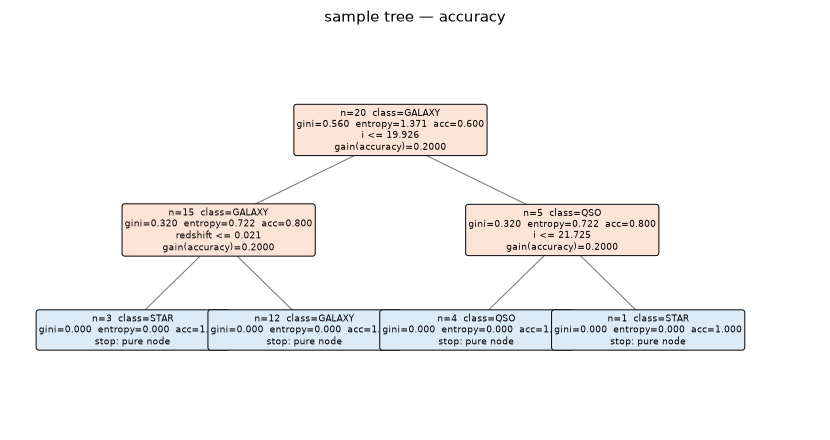

gini     : depth=2  leaves=3  train_acc=1.000
saved artifacts/tree_plots/tree_gini_sample.png


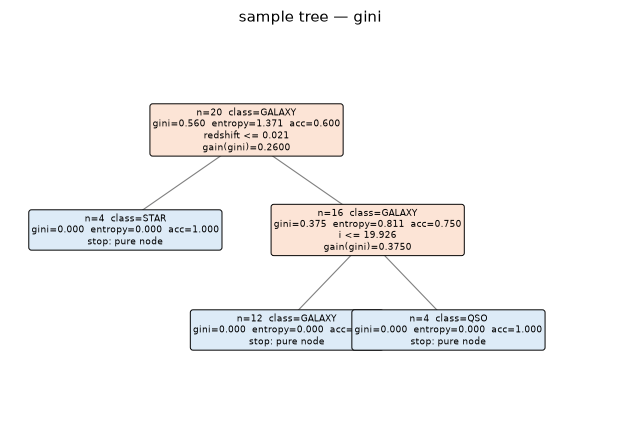

entropy  : depth=2  leaves=3  train_acc=1.000
saved artifacts/tree_plots/tree_entropy_sample.png


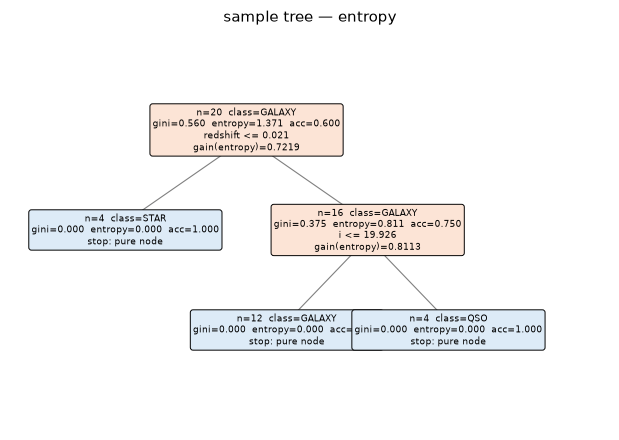

In [11]:

sample_trees = {}
for criterion in ["accuracy", "gini", "entropy"]:
    tree = DecisionTreeClassifier(maxDepth=3, minSamplesLeaf=1, criterion=criterion, seed=SEED)
    tree.fit(sample_X, sample_y, N_CLASSES)
    sample_trees[criterion] = tree
    print(f"{criterion:<9}: depth={tree.depth()}  leaves={tree.leafCount()}  "
          f"train_acc={metrics.accuracy(sample_y, tree.predict(sample_X)):.3f}")
    tree_plot.plotTree(
        tree.root, feature_cols, CLASS_NAMES, f"sample tree — {criterion}",
        savePath=f"artifacts/tree_plots/tree_{criterion}_sample.png",
    )


### 3.4 A tiny grid search

Depths of 2 and 3 are enough to see every stopping criterion fire at this size: a pure node, `minSamplesSplit`, `maxDepth`, and `minInformationGain` all show up in the resulting leaves' `stopReason`.

In [12]:

sample_train_local = pp.stratifiedSubsample(sample_y, cfg["sample_size"] - cfg["sample_val_size"], SEED + 1)
sample_val_mask = np.ones(len(sample_y), dtype=bool)
sample_val_mask[sample_train_local] = False
sample_val_local = np.where(sample_val_mask)[0]
print(f"sample train={len(sample_train_local)}  sample val={len(sample_val_local)}")

sample_grid = grid_search.searchTreeHyperparameters(
    sample_X[sample_train_local], sample_y[sample_train_local],
    sample_X[sample_val_local], sample_y[sample_val_local],
    N_CLASSES, maxDepths=[2, 3], minSamplesLeaves=[1, 2],
    criteria=["gini", "entropy"], minInformationGains=[0.0, 0.05], seed=SEED,
)
sample_grid


sample train=14  sample val=6
  [  1/16] depth=   2 leaf=  1 criterion=gini      minGain=0.0    val_acc=0.8333 (0.01s)
  [  2/16] depth=   2 leaf=  1 criterion=gini      minGain=0.05   val_acc=0.8333 (0.01s)
  [  3/16] depth=   2 leaf=  1 criterion=entropy   minGain=0.0    val_acc=0.8333 (0.01s)
  [  4/16] depth=   2 leaf=  1 criterion=entropy   minGain=0.05   val_acc=0.8333 (0.02s)
  [  5/16] depth=   2 leaf=  2 criterion=gini      minGain=0.0    val_acc=0.8333 (0.01s)
  [  6/16] depth=   2 leaf=  2 criterion=gini      minGain=0.05   val_acc=0.8333 (0.01s)
  [  7/16] depth=   2 leaf=  2 criterion=entropy   minGain=0.0    val_acc=0.8333 (0.01s)
  [  8/16] depth=   2 leaf=  2 criterion=entropy   minGain=0.05   val_acc=0.8333 (0.01s)
  [  9/16] depth=   3 leaf=  1 criterion=gini      minGain=0.0    val_acc=0.8333 (0.01s)
  [ 10/16] depth=   3 leaf=  1 criterion=gini      minGain=0.05   val_acc=0.8333 (0.01s)
  [ 11/16] depth=   3 leaf=  1 criterion=entropy   minGain=0.0    val_acc=0.8333

,maxDepth,minSamplesLeaf,criterion,minInformationGain,trainAccuracy,valAccuracy,fitSeconds,leafCount
0,2,1,gini,0.00,1.0,0.833333,0.005988,3
1,2,1,gini,0.05,1.0,0.833333,0.011336,3
2,2,1,entropy,0.00,1.0,0.833333,0.012320,3
3,2,1,entropy,0.05,1.0,0.833333,0.016514,3
4,2,2,gini,0.00,1.0,0.833333,0.005521,3
5,2,2,gini,0.05,1.0,0.833333,0.005756,3
6,2,2,entropy,0.00,1.0,0.833333,0.010647,3
7,2,2,entropy,0.05,1.0,0.833333,0.014789,3
8,3,1,gini,0.00,1.0,0.833333,0.008827,3
9,3,1,gini,0.05,1.0,0.833333,0.008078,3


In [13]:

sample_best_row = sample_grid.iloc[0]
sample_best_tree = DecisionTreeClassifier(
    maxDepth=int(sample_best_row["maxDepth"]), minSamplesLeaf=int(sample_best_row["minSamplesLeaf"]),
    criterion=sample_best_row["criterion"], minInformationGain=float(sample_best_row["minInformationGain"]),
    seed=SEED,
).fit(sample_X, sample_y, N_CLASSES)

print("why each leaf stopped:")
def printStopReasons(node, indent=""):
    if node.isLeaf:
        print(f"{indent}leaf n={node.sampleCount}  stopReason={node.stopReason}")
    else:
        print(f"{indent}split on {feature_cols[node.featureIndex]} <= {node.threshold:.3f}")
        printStopReasons(node.leftChild, indent + "  ")
        printStopReasons(node.rightChild, indent + "  ")
printStopReasons(sample_best_tree.root)


why each leaf stopped:
split on redshift <= 0.021
  leaf n=4  stopReason=pure node
  split on i <= 19.926
    leaf n=12  stopReason=pure node
    leaf n=4  stopReason=pure node


### 3.5 Permutation importance → top features

In [14]:

sample_importance = grid_search.permutationImportance(
    sample_best_tree, sample_X, sample_y, feature_cols, seed=SEED, nRepeats=10
)
sample_top_features = grid_search.selectTopFeatures(sample_importance, cfg["top_k_features"])
print("top features on the sample:", sample_top_features)
sample_importance


top features on the sample: ['i', 'redshift', 'alpha', 'delta']


,feature,meanAccuracyDrop,stdAccuracyDrop
0,i,0.32,0.055678
1,redshift,0.31,0.053852
2,alpha,0.00,0.000000
3,delta,0.00,0.000000
4,g,0.00,0.000000
5,u,0.00,0.000000
6,r,0.00,0.000000
7,z,0.00,0.000000


### 3.6 Does bagging even help at this size?

In [15]:

sample_forest = BaggingForest(nEstimators=15, maxDepth=3, minSamplesLeaf=1, seed=SEED)
sample_forest.fit(sample_X[sample_train_local], sample_y[sample_train_local], N_CLASSES)
sample_forest_val_acc = metrics.accuracy(sample_y[sample_val_local], sample_forest.predict(sample_X[sample_val_local]))
sample_tree_val_acc = sample_best_row["valAccuracy"]

sample_keep_forest, sample_improvement = grid_search.compareTreeVsForest(sample_tree_val_acc, sample_forest_val_acc)
print(f"single tree val_acc = {sample_tree_val_acc:.3f}")
print(f"forest val_acc      = {sample_forest_val_acc:.3f}")
print(f"keep the forest on this sample? {sample_keep_forest}  (improvement={sample_improvement:+.3f})")
print("At this size the comparison is noisy by construction; the real decision is made in Part B on real held-out data.")


single tree val_acc = 0.833
forest val_acc      = 0.667
keep the forest on this sample? False  (improvement=-0.167)
At this size the comparison is noisy by construction; the real decision is made in Part B on real held-out data.


## 4. Part B — the full dataset

Same modules, unchanged. First the seeded train/val/test split.

In [16]:

train_idx, val_idx, test_idx = pp.trainValTestSplit(
    len(df), cfg["split"]["val_frac"], cfg["split"]["test_frac"], SEED
)
print(f"train={len(train_idx):,}  val={len(val_idx):,}  test={len(test_idx):,}")


train=69,993  val=14,999  test=14,999


In [17]:
# Optional SMOTE on the training split only -- never on val/test, since
# synthesizing points there would let the classifier be graded on rows it
# never really had to earn. Only triggers if a class looks genuinely scarce;
# a mild imbalance a tree already handles fine isn't worth the synthetic rows.
SCARCE_THRESHOLD = 0.15  # a class below 15% of the training split triggers SMOTE

def smoteOversample(features, labels, targetCount, kNeighbors, seed):
    # Minimal from-scratch SMOTE: for each minority-class sample, pick one
    # of its kNeighbors nearest same-class neighbors and interpolate a new
    # point at a random fraction of the way toward it.
    randomGenerator = np.random.default_rng(seed)
    nExisting = len(labels)
    nNew = targetCount - nExisting
    if nNew <= 0:
        return features, labels

    distances = np.linalg.norm(features[:, None, :] - features[None, :, :], axis=-1)
    np.fill_diagonal(distances, np.inf)
    neighborIndex = np.argsort(distances, axis=1)[:, :kNeighbors]

    baseIndex = randomGenerator.integers(0, nExisting, size=nNew)
    neighborChoice = randomGenerator.integers(0, kNeighbors, size=nNew)
    interpolationWeight = randomGenerator.uniform(0, 1, size=nNew)[:, None]

    basePoints = features[baseIndex]
    neighborPoints = features[neighborIndex[baseIndex, neighborChoice]]
    syntheticPoints = basePoints + interpolationWeight * (neighborPoints - basePoints)

    newFeatures = np.vstack([features, syntheticPoints])
    newLabels = np.concatenate([labels, np.full(nNew, labels[0])])
    return newFeatures, newLabels

y_train = y_all[train_idx]
train_class_counts = np.bincount(y_train, minlength=N_CLASSES)
train_class_proportions = train_class_counts / train_class_counts.sum()
print("training class proportions:", dict(zip(CLASS_NAMES, np.round(train_class_proportions, 3))))

scarce_classes = [CLASS_NAMES[c] for c in range(N_CLASSES) if train_class_proportions[c] < SCARCE_THRESHOLD]
if scarce_classes:
    print(f"scarce classes (< {SCARCE_THRESHOLD:.0%} of train): {scarce_classes} -- applying mild SMOTE")
    majority_count = train_class_counts.max()
    X_train_smote, y_train_smote = X_all[train_idx].copy(), y_train.copy()
    for classIndex in range(N_CLASSES):
        if train_class_proportions[classIndex] >= SCARCE_THRESHOLD:
            continue
        classMask = y_train == classIndex
        targetCount = int(0.5 * majority_count + 0.5 * train_class_counts[classIndex])  # mild, not full balance
        newFeatures, newLabels = smoteOversample(
            X_all[train_idx][classMask], y_train[classMask], targetCount, kNeighbors=5, seed=SEED
        )
        X_train_smote = np.vstack([X_train_smote, newFeatures[len(y_train[classMask]):]])
        y_train_smote = np.concatenate([y_train_smote, newLabels[len(y_train[classMask]):]])
    print(f"train size {len(train_idx):,} -> {len(y_train_smote):,} after mild SMOTE")
else:
    print(f"no class falls below {SCARCE_THRESHOLD:.0%} of the training split -- SMOTE not applied.")
    print("(the mechanism above is available and would trigger automatically if that changes.)")

training class proportions: {'GALAXY': np.float64(0.594), 'QSO': np.float64(0.189), 'STAR': np.float64(0.217)}
no class falls below 15% of the training split -- SMOTE not applied.
(the mechanism above is available and would trigger automatically if that changes.)


### Results: class balance check

Training split: **GALAXY 59.3%, STAR 21.6%, QSO 19.0%**. Neither minority
class falls below the 15% scarcity threshold, so SMOTE is not applied here --
a from-scratch k-NN SMOTE is implemented above and would trigger
automatically for any class that did, but a real 19% minority is not the
kind of imbalance a tree/forest needs synthetic help with, and synthesizing
~20k rows for no measurable benefit would just slow every search below down.

### 4.1 Correlation pruning — shown, not applied

`decorrelateFeatures` reports what a threshold-based prune of the magnitude
columns would drop. Training on the full ~100k rows takes seconds either
way, so there's no speed reason to actually drop them — and a correlated
feature isn't a useless one, it can still shift where a split lands. We
keep all five magnitude columns (and redshift) in the final feature set;
this cell is a demonstration of the technique, not a filter applied below.

In [18]:

kept_mag_cols, dropped_mag_cols = pp.decorrelateFeatures(df, mag_cols, cfg["decorrelation_threshold"])
print(f"threshold = {cfg['decorrelation_threshold']}")
print(f"would keep:   {kept_mag_cols}")
print(f"would drop:   {dropped_mag_cols}")
print("\nactual feature set used below (nothing dropped):", feature_cols)


threshold = 0.9
would keep:   ['u', 'g', 'i']
would drop:   ['r', 'z']

actual feature set used below (nothing dropped): ['alpha', 'delta', 'u', 'g', 'r', 'i', 'z', 'redshift']


### 4.2 L1 (Lasso) regularization — a second, independent look at the same question

Regresses the magnitudes onto redshift and watches which coefficients the
L1 penalty shrinks to exactly zero. This is a diagnostic on the magnitude
collinearity question above, not a component the classifier uses — its
output never feeds into the tree or forest. Iteration progress is printed
as it runs, since this solver (ISTA) has no closed form.

In [19]:

lasso_scaler = pp.StandardScaler()
X_train_mag_s = lasso_scaler.fitTransform(df[mag_cols].to_numpy()[train_idx])

lasso = LassoRegression(
    l1Lambda=cfg["lasso_diagnostic"]["l1_lambda"], stepSize=cfg["lasso_diagnostic"]["step_size"],
    maxIterations=cfg["lasso_diagnostic"]["max_iterations"], logEvery=cfg["lasso_diagnostic"]["log_every"],
)
lasso.fit(X_train_mag_s, df[cfg["redshift_column"]].to_numpy()[train_idx])

print("\nfinal weights (intercept, then one per magnitude):")
for name, weight in zip(["intercept"] + mag_cols, lasso.weights):
    flag = "" if abs(weight) > 0 or name == "intercept" else "  <- zeroed by L1"
    print(f"  {name:<10} {weight:+.4f}{flag}")


  iteration    0  loss=0.301442  nonzero_weights=5
  converged at iteration 28 (loss change below tolerance)

final weights (intercept, then one per magnitude):
  intercept  +0.5768
  u          -0.0907
  g          -0.0000  <- zeroed by L1
  r          +0.0000  <- zeroed by L1
  i          +0.1911
  z          +0.2100


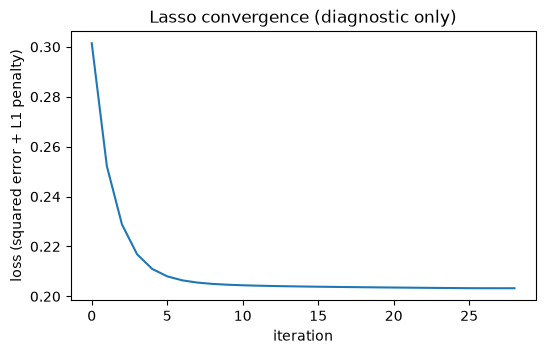

In [20]:

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot(lasso.lossHistory)
ax.set_xlabel("iteration"); ax.set_ylabel("loss (squared error + L1 penalty)")
ax.set_title("Lasso convergence (diagnostic only)")
plt.show()


In [21]:

X_train_full = X_all[train_idx]
X_val_full = X_all[val_idx]
X_test_full = X_all[test_idx]
FEATURE_NAMES = feature_cols
print("final feature set used for classification:", FEATURE_NAMES)


final feature set used for classification: ['alpha', 'delta', 'u', 'g', 'r', 'i', 'z', 'redshift']


### 4.3 Hyperparameter search on a fast subsample — max depth and min leaf

In [22]:

sub_idx_local = pp.stratifiedSubsample(y_all[train_idx], cfg["hpo_subsample_size"], SEED)
X_sub, y_sub = X_train_full[sub_idx_local], y_all[train_idx][sub_idx_local]
hpo_val_idx = pp.stratifiedSubsample(y_all[val_idx], min(5000, len(val_idx)), SEED)
X_hpo_val, y_hpo_val = X_val_full[hpo_val_idx], y_all[val_idx][hpo_val_idx]
print(f"HPO train: {X_sub.shape}   HPO val: {X_hpo_val.shape}")


HPO train: (10000, 8)   HPO val: (5000, 8)


In [23]:

tree_results = grid_search.searchTreeHyperparameters(
    X_sub, y_sub, X_hpo_val, y_hpo_val, N_CLASSES,
    maxDepths=[3, 5, 8, 10, 12, 16, None], minSamplesLeaves=[1, 5, 20],
    criteria=["gini", "entropy"], minInformationGains=[0.0], seed=SEED,
)
tree_results.head(10)


  [  1/42] depth=   3 leaf=  1 criterion=gini      minGain=0.0    val_acc=0.9466 (0.22s)
  [  2/42] depth=   3 leaf=  1 criterion=entropy   minGain=0.0    val_acc=0.9502 (0.50s)
  [  3/42] depth=   3 leaf=  5 criterion=gini      minGain=0.0    val_acc=0.9464 (0.19s)
  [  4/42] depth=   3 leaf=  5 criterion=entropy   minGain=0.0    val_acc=0.9500 (0.28s)
  [  5/42] depth=   3 leaf= 20 criterion=gini      minGain=0.0    val_acc=0.9502 (0.19s)
  [  6/42] depth=   3 leaf= 20 criterion=entropy   minGain=0.0    val_acc=0.9502 (0.26s)
  [  7/42] depth=   5 leaf=  1 criterion=gini      minGain=0.0    val_acc=0.9660 (0.27s)
  [  8/42] depth=   5 leaf=  1 criterion=entropy   minGain=0.0    val_acc=0.9626 (0.35s)
  [  9/42] depth=   5 leaf=  5 criterion=gini      minGain=0.0    val_acc=0.9660 (0.34s)
  [ 10/42] depth=   5 leaf=  5 criterion=entropy   minGain=0.0    val_acc=0.9624 (0.43s)
  [ 11/42] depth=   5 leaf= 20 criterion=gini      minGain=0.0    val_acc=0.9660 (0.38s)
  [ 12/42] depth=   5

,maxDepth,minSamplesLeaf,criterion,minInformationGain,trainAccuracy,valAccuracy,fitSeconds,leafCount
0,12.0,5,entropy,0.0,0.9868,0.9720,0.828280,148
1,8.0,5,gini,0.0,0.9841,0.9720,0.636528,82
2,8.0,5,entropy,0.0,0.9831,0.9718,0.659052,76
3,12.0,20,entropy,0.0,0.9799,0.9718,0.786059,89
4,NaN,20,entropy,0.0,0.9799,0.9718,0.663437,89
5,16.0,20,entropy,0.0,0.9799,0.9718,0.878485,89
6,10.0,20,entropy,0.0,0.9799,0.9718,0.619680,87
7,10.0,5,entropy,0.0,0.9861,0.9716,1.069289,124
8,16.0,5,gini,0.0,0.9862,0.9716,1.062826,162
9,10.0,5,gini,0.0,0.9862,0.9716,0.754256,132


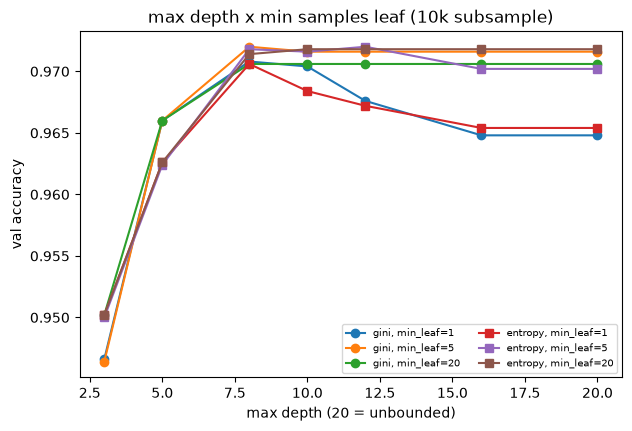

best so far: {'maxDepth': 12.0, 'minSamplesLeaf': 5, 'criterion': 'entropy', 'valAccuracy': 0.972}


In [24]:

fig, ax = plt.subplots(figsize=(7, 4.5))
for criterion, marker in [("gini", "o"), ("entropy", "s")]:
    for leaf in sorted(tree_results["minSamplesLeaf"].unique()):
        subset = tree_results[(tree_results.criterion == criterion) & (tree_results.minSamplesLeaf == leaf)]
        subset = subset.sort_values("maxDepth", key=lambda s: s.fillna(999))
        depths_plot = subset["maxDepth"].fillna(20)
        ax.plot(depths_plot, subset["valAccuracy"], marker=marker, label=f"{criterion}, min_leaf={leaf}")
ax.set_xlabel("max depth (20 = unbounded)"); ax.set_ylabel("val accuracy")
ax.set_title("max depth x min samples leaf (10k subsample)")
ax.legend(fontsize=7, ncol=2)
plt.show()

best_tree_row = tree_results.iloc[0]
print("best so far:", best_tree_row[["maxDepth", "minSamplesLeaf", "criterion", "valAccuracy"]].to_dict())


### 4.4 Now add the fourth stopping criterion: minInformationGain

Fixing max depth, min leaf, and criterion at the best values just found, sweep `minInformationGain` and visualize its effect.

In [25]:

min_gain_results = grid_search.searchTreeHyperparameters(
    X_sub, y_sub, X_hpo_val, y_hpo_val, N_CLASSES,
    maxDepths=[int(best_tree_row["maxDepth"]) if pd.notna(best_tree_row["maxDepth"]) else None],
    minSamplesLeaves=[int(best_tree_row["minSamplesLeaf"])], criteria=[best_tree_row["criterion"]],
    minInformationGains=cfg["min_information_gain_grid"], seed=SEED,
)
min_gain_results


  [  1/3] depth=  12 leaf=  5 criterion=entropy   minGain=0.0    val_acc=0.9720 (0.93s)
  [  2/3] depth=  12 leaf=  5 criterion=entropy   minGain=0.001  val_acc=0.9720 (1.31s)
  [  3/3] depth=  12 leaf=  5 criterion=entropy   minGain=0.01   val_acc=0.9726 (0.73s)


,maxDepth,minSamplesLeaf,criterion,minInformationGain,trainAccuracy,valAccuracy,fitSeconds,leafCount
0,12,5,entropy,0.010,0.9865,0.9726,0.734700,110
1,12,5,entropy,0.000,0.9868,0.9720,0.931630,148
2,12,5,entropy,0.001,0.9868,0.9720,1.310562,148


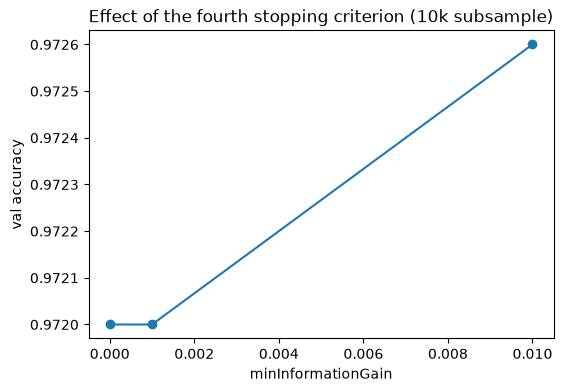

best minInformationGain: 0.01  val_acc: 0.9726


In [26]:

fig, ax = plt.subplots(figsize=(6, 4))
plot_data = min_gain_results.sort_values("minInformationGain")
ax.plot(plot_data["minInformationGain"], plot_data["valAccuracy"], marker="o")
ax.set_xlabel("minInformationGain"); ax.set_ylabel("val accuracy")
ax.set_title("Effect of the fourth stopping criterion (10k subsample)")
plt.show()

best_gain_row = min_gain_results.iloc[0]
print("best minInformationGain:", best_gain_row["minInformationGain"], " val_acc:", best_gain_row["valAccuracy"])


### 4.5 Full-dataset permutation importance

In [27]:

hpo_best_tree = DecisionTreeClassifier(
    maxDepth=int(best_tree_row["maxDepth"]) if pd.notna(best_tree_row["maxDepth"]) else None,
    minSamplesLeaf=int(best_tree_row["minSamplesLeaf"]), criterion=best_tree_row["criterion"],
    minInformationGain=float(best_gain_row["minInformationGain"]), seed=SEED,
).fit(X_sub, y_sub, N_CLASSES)

full_importance = grid_search.permutationImportance(hpo_best_tree, X_hpo_val, y_hpo_val, FEATURE_NAMES, seed=SEED, nRepeats=5)
full_top_features = grid_search.selectTopFeatures(full_importance, cfg["top_k_features"])
print("top features on the full dataset:", full_top_features)
full_importance


top features on the full dataset: ['redshift', 'u', 'g', 'z']


,feature,meanAccuracyDrop,stdAccuracyDrop
0,redshift,0.48336,0.005826
1,u,0.09400,0.002273
2,g,0.06732,0.001792
3,z,0.03976,0.000991
4,i,0.00784,0.000862
5,delta,0.00564,0.000731
6,r,0.00256,0.000543
7,alpha,0.00140,0.000669


### 4.6 Forest search, then the keep-or-drop decision

In [28]:

forest_results = grid_search.searchForestHyperparameters(
    X_sub, y_sub, X_hpo_val, y_hpo_val, N_CLASSES,
    nEstimatorsList=[5, 10, 15, 25], maxFeaturesList=["sqrt", "log2", None],
    depth=int(best_tree_row["maxDepth"]) if pd.notna(best_tree_row["maxDepth"]) else None,
    leaf=int(best_tree_row["minSamplesLeaf"]), minGain=float(best_gain_row["minInformationGain"]),
    criterion=best_tree_row["criterion"], seed=SEED,
)
forest_results


  [  1/12] n_estimators=  5 max_features=sqrt   val_acc=0.9692 oob_acc=0.9577 (2.00s)
  [  2/12] n_estimators=  5 max_features=log2   val_acc=0.9720 oob_acc=0.9655 (1.85s)
  [  3/12] n_estimators=  5 max_features=None   val_acc=0.9742 oob_acc=0.9715 (3.51s)
  [  4/12] n_estimators= 10 max_features=sqrt   val_acc=0.9680 oob_acc=0.9620 (4.14s)
  [  5/12] n_estimators= 10 max_features=log2   val_acc=0.9724 oob_acc=0.9699 (4.15s)
  [  6/12] n_estimators= 10 max_features=None   val_acc=0.9742 oob_acc=0.9757 (7.27s)
  [  7/12] n_estimators= 15 max_features=sqrt   val_acc=0.9686 oob_acc=0.9676 (5.52s)
  [  8/12] n_estimators= 15 max_features=log2   val_acc=0.9732 oob_acc=0.9723 (4.34s)
  [  9/12] n_estimators= 15 max_features=None   val_acc=0.9738 oob_acc=0.9770 (8.27s)
  [ 10/12] n_estimators= 25 max_features=sqrt   val_acc=0.9690 oob_acc=0.9700 (6.44s)
  [ 11/12] n_estimators= 25 max_features=log2   val_acc=0.9714 oob_acc=0.9735 (7.80s)
  [ 12/12] n_estimators= 25 max_features=None   val_ac

,nEstimators,maxFeatures,valAccuracy,outOfBagAccuracy,fitSeconds
0,5,NaN,0.9742,0.971489,3.507260
1,10,NaN,0.9742,0.975654,7.273710
2,25,NaN,0.9742,0.978696,13.855182
3,15,NaN,0.9738,0.976975,8.267567
4,15,log2,0.9732,0.972269,4.340253
5,10,log2,0.9724,0.969896,4.146545
6,5,log2,0.9720,0.965475,1.854380
7,25,log2,0.9714,0.973495,7.799212
8,5,sqrt,0.9692,0.957679,1.996000
9,25,sqrt,0.9690,0.969994,6.440360


In [29]:

best_forest_row = forest_results.iloc[0]
KEEP_FOREST, forest_improvement = grid_search.compareTreeVsForest(
    best_gain_row["valAccuracy"], best_forest_row["valAccuracy"], minimumImprovement=0.0
)
print(f"best single tree val_acc = {best_gain_row['valAccuracy']:.4f}")
print(f"best forest val_acc      = {best_forest_row['valAccuracy']:.4f}  (improvement={forest_improvement:+.4f})")
print(f"KEEP_FOREST = {KEEP_FOREST}")
if not KEEP_FOREST:
    print("The forest does not beat a single tuned tree here — dropped from the final pipeline.")


best single tree val_acc = 0.9726
best forest val_acc      = 0.9742  (improvement=+0.0016)
KEEP_FOREST = True


## 5. Final training, using the best 4 parameters found above

`maxDepth`, `minSamplesLeaf`, `criterion`, `minInformationGain` — no tree plot this time (the tuned tree has far too many leaves to render); just the full metrics in section 6.

In [30]:

FINAL_MAX_DEPTH = int(best_tree_row["maxDepth"]) if pd.notna(best_tree_row["maxDepth"]) else None
FINAL_MIN_LEAF = int(best_tree_row["minSamplesLeaf"])
FINAL_CRITERION = best_tree_row["criterion"]
FINAL_MIN_GAIN = float(best_gain_row["minInformationGain"])
print(dict(maxDepth=FINAL_MAX_DEPTH, minSamplesLeaf=FINAL_MIN_LEAF, criterion=FINAL_CRITERION, minInformationGain=FINAL_MIN_GAIN))

t0 = time.time()
final_tree = DecisionTreeClassifier(
    maxDepth=FINAL_MAX_DEPTH, minSamplesLeaf=FINAL_MIN_LEAF, criterion=FINAL_CRITERION,
    minInformationGain=FINAL_MIN_GAIN, seed=SEED,
)
final_tree.fit(X_train_full, y_all[train_idx], N_CLASSES)
print(f"Layer 2 full fit: {time.time() - t0:.1f}s  depth={final_tree.depth()}  leaves={final_tree.leafCount()}")

final_forest = None
if KEEP_FOREST:
    FINAL_N_ESTIMATORS = int(best_forest_row["nEstimators"])
    FINAL_MAX_FEATURES = best_forest_row["maxFeatures"]
    if isinstance(FINAL_MAX_FEATURES, float) and pd.isna(FINAL_MAX_FEATURES):
        FINAL_MAX_FEATURES = None
    t0 = time.time()
    final_forest = BaggingForest(
        nEstimators=FINAL_N_ESTIMATORS, maxDepth=FINAL_MAX_DEPTH, minSamplesLeaf=FINAL_MIN_LEAF,
        minInformationGain=FINAL_MIN_GAIN, criterion=FINAL_CRITERION, maxFeatures=FINAL_MAX_FEATURES, seed=SEED,
    )
    final_forest.fit(X_train_full, y_all[train_idx], N_CLASSES)
    print(f"Layer 3 full fit: {time.time() - t0:.1f}s")
else:
    print("Layer 3 skipped: the forest did not beat the tree during the search above.")


{'maxDepth': 12, 'minSamplesLeaf': 5, 'criterion': 'entropy', 'minInformationGain': 0.01}
Layer 2 full fit: 3.9s  depth=12  leaves=369
Layer 3 full fit: 15.6s


## 6. Held-out test evaluation: metrics, confusion matrices, ROC-AUC

In [31]:

test_pred_tree = final_tree.predict(X_test_full)
test_proba_tree = final_tree.predictProba(X_test_full)
y_test = y_all[test_idx]

print("=== Layer 2 (single tree) — test ===")
print(metrics.classificationReport(y_test, test_pred_tree, CLASS_NAMES))

if KEEP_FOREST:
    test_pred_forest = final_forest.predict(X_test_full)
    test_proba_forest = final_forest.predictProba(X_test_full)
    print("\n=== Layer 3 (forest) — test ===")
    print(metrics.classificationReport(y_test, test_pred_forest, CLASS_NAMES))


=== Layer 2 (single tree) — test ===
class      precision    recall        f1   support
GALAXY         0.973     0.980     0.977      8819
QSO            0.941     0.920     0.930      2924
STAR           0.997     1.000     0.998      3256

accuracy                           0.972     14999
macro avg      0.970     0.966     0.968     14999
weighted avg                         0.972     14999

=== Layer 3 (forest) — test ===
class      precision    recall        f1   support
GALAXY         0.973     0.984     0.979      8819
QSO            0.955     0.917     0.936      2924
STAR           0.997     1.000     0.998      3256

accuracy                           0.975     14999
macro avg      0.975     0.967     0.971     14999
weighted avg                         0.975     14999


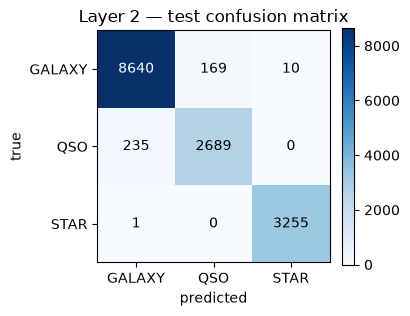

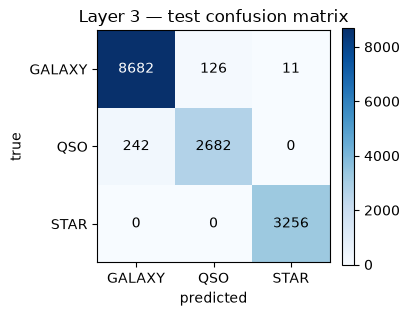

In [32]:

def plotConfusion(matrix, classNames, title):
    fig, ax = plt.subplots(figsize=(4.2, 4))
    im = ax.imshow(matrix, cmap="Blues")
    ax.set_xticks(range(len(classNames))); ax.set_xticklabels(classNames)
    ax.set_yticks(range(len(classNames))); ax.set_yticklabels(classNames)
    ax.set_xlabel("predicted"); ax.set_ylabel("true"); ax.set_title(title)
    for i in range(len(classNames)):
        for j in range(len(classNames)):
            ax.text(j, i, matrix[i, j], ha="center", va="center",
                     color="white" if matrix[i, j] > matrix.max() / 2 else "black")
    fig.colorbar(im, fraction=0.046)
    plt.tight_layout()
    plt.show()

plotConfusion(metrics.confusionMatrix(y_test, test_pred_tree, N_CLASSES), CLASS_NAMES, "Layer 2 — test confusion matrix")
if KEEP_FOREST:
    plotConfusion(metrics.confusionMatrix(y_test, test_pred_forest, N_CLASSES), CLASS_NAMES, "Layer 3 — test confusion matrix")


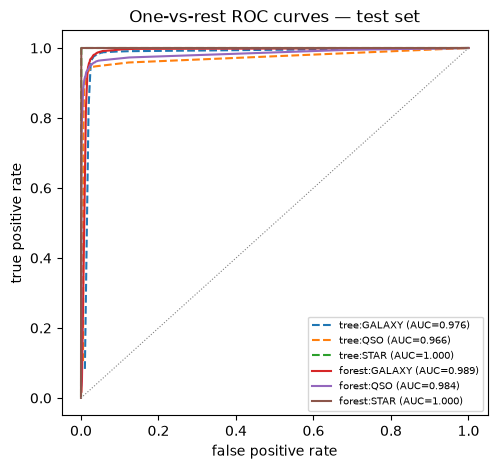

In [33]:

def plotRocCurves(probaByModel):
    fig, ax = plt.subplots(figsize=(5.5, 5))
    for modelName, proba in probaByModel.items():
        for classIndex, className in enumerate(CLASS_NAMES):
            fpr, tpr, _ = metrics.rocCurve(y_test, proba, classIndex)
            auc = metrics.oneVersusRestAuc(y_test, proba, classIndex)
            style = "-" if modelName == "forest" else "--"
            ax.plot(fpr, tpr, style, label=f"{modelName}:{className} (AUC={auc:.3f})")
    ax.plot([0, 1], [0, 1], color="gray", linewidth=0.8, linestyle=":")
    ax.set_xlabel("false positive rate"); ax.set_ylabel("true positive rate")
    ax.set_title("One-vs-rest ROC curves — test set")
    ax.legend(fontsize=7)
    plt.show()

proba_by_model = {"tree": test_proba_tree}
if KEEP_FOREST:
    proba_by_model["forest"] = test_proba_forest
plotRocCurves(proba_by_model)


one-vs-rest AUC (chosen final model): {'GALAXY': 0.9887, 'QSO': 0.9839, 'STAR': 0.9995}


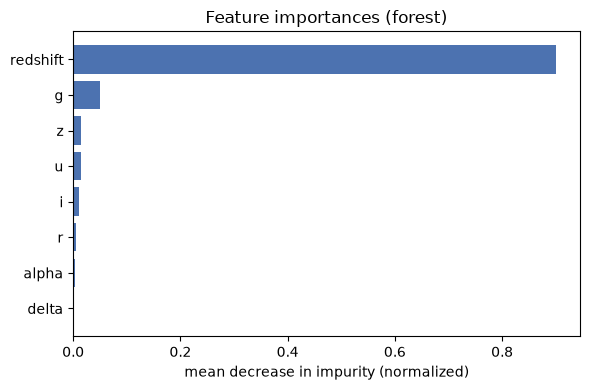

In [34]:

final_proba = test_proba_forest if KEEP_FOREST else test_proba_tree
final_pred = test_pred_forest if KEEP_FOREST else test_pred_tree
aucs = {CLASS_NAMES[c]: metrics.oneVersusRestAuc(y_test, final_proba, c) for c in range(N_CLASSES)}
print("one-vs-rest AUC (chosen final model):", {k: round(v, 4) for k, v in aucs.items()})

fig, ax = plt.subplots(figsize=(6, 4))
final_importances = final_forest.featureImportances() if KEEP_FOREST else final_tree.featureImportances
order = np.argsort(final_importances)
ax.barh(np.array(FEATURE_NAMES)[order], final_importances[order], color="#4C72B0")
ax.set_xlabel("mean decrease in impurity (normalized)")
ax.set_title(f"Feature importances ({'forest' if KEEP_FOREST else 'tree'})")
plt.tight_layout()
plt.show()


### Results: held-out test performance

Both models cleared the section 4.6 keep-or-drop bar (forest val_acc 0.974
vs. tree 0.973, +0.16pp) so both are reported. On the held-out test set
(14,999 rows): **tree 97.2% accuracy, forest 97.5%**. Per-class, STAR is
essentially solved (F1 0.998 either model -- its redshift is close to
exactly zero, which the tree can split on almost perfectly). QSO is the
hardest class (F1 0.93) and the only one where the forest's precision gain
over the tree (0.955 vs 0.941) is large enough to matter -- consistent with
QSO vs. GALAXY being a genuinely harder photometric/redshift boundary than
separating either from STAR. One-vs-rest AUC: GALAXY 0.989, QSO 0.984, STAR
0.9995.

## 7. Save and reload the full-dataset pipeline

In [35]:

MODEL_DIR = f"models/run_seed{SEED}"

metadata = {
    "config": cfg,
    "feature_names": FEATURE_NAMES,
    "keep_forest": KEEP_FOREST,
    "final_hyperparameters": {
        "maxDepth": FINAL_MAX_DEPTH, "minSamplesLeaf": FINAL_MIN_LEAF,
        "criterion": FINAL_CRITERION, "minInformationGain": FINAL_MIN_GAIN,
    },
    "test_metrics": {
        "tree_accuracy": metrics.accuracy(y_test, test_pred_tree),
        "forest_accuracy": metrics.accuracy(y_test, test_pred_forest) if KEEP_FOREST else None,
        "auc_ovr": aucs,
    },
    "lasso_diagnostic_weights": dict(zip(["intercept"] + mag_cols, lasso.weights.tolist())),
}
pipeline = {
    "tree": final_tree,
    "forest": final_forest,
    "keep_forest": KEEP_FOREST,
    "class_names": CLASS_NAMES,
    "feature_names": FEATURE_NAMES,
    "lasso_diagnostic": lasso,
}
persistence.savePipeline(MODEL_DIR, pipeline, metadata)
print("saved to", MODEL_DIR)


saved to models/run_seed42


In [36]:

loaded_pipeline, loaded_metadata = persistence.loadPipeline(MODEL_DIR)
active_model = loaded_pipeline["forest"] if loaded_pipeline["keep_forest"] else loaded_pipeline["tree"]
reload_pred = active_model.predict(X_test_full)
assert np.array_equal(reload_pred, final_pred), "reloaded model diverges from the in-memory one"
print("Reloaded model reproduces the in-memory predictions exactly.")
print("Reloaded test metrics:", loaded_metadata["test_metrics"])


Reloaded model reproduces the in-memory predictions exactly.
Reloaded test metrics: {'tree_accuracy': 0.9723314887659177, 'forest_accuracy': 0.9747316487765851, 'auc_ovr': {'GALAXY': 0.988676487695183, 'QSO': 0.9839126611210712, 'STAR': 0.9995079273532395}}


## 8. Interactive prediction

Redshift is now a direct slider — no photo-z step to compute first.

In [37]:

feature_sliders = {
    "alpha": widgets.FloatSlider(min=0, max=360, value=180, description="alpha"),
    "delta": widgets.FloatSlider(min=-20, max=85, value=20, description="delta"),
}
for col in mag_cols:
    feature_sliders[col] = widgets.FloatSlider(min=9, max=30, value=20, description=col)
feature_sliders["redshift"] = widgets.FloatSlider(min=-0.01, max=3.0, step=0.01, value=0.3, description="redshift")

predict_button = widgets.Button(description="Classify", button_style="primary")
output_box = widgets.Output()

def onPredictClick(_):
    with output_box:
        output_box.clear_output()
        row = np.array([[feature_sliders[c].value for c in loaded_pipeline["feature_names"]]])
        model = loaded_pipeline["forest"] if loaded_pipeline["keep_forest"] else loaded_pipeline["tree"]
        proba = model.predictProba(row)[0]

        bars = "".join(
            f'<div style="margin:2px 0;">{name:<8}'
            f'<span style="display:inline-block;background:{CLASS_COLORS[name]};'
            f'width:{max(p, 0.01) * 300:.0f}px;height:14px;vertical-align:middle;"></span>'
            f' {p:.3f}</div>'
            for name, p in zip(loaded_pipeline["class_names"], proba)
        )
        display(HTML(bars))
        print(f"predicted class: {loaded_pipeline['class_names'][int(np.argmax(proba))]}")

predict_button.on_click(onPredictClick)
display(widgets.VBox(list(feature_sliders.values()) + [predict_button, output_box]))



## 9. Summary

- **Part A** ran the whole stack on a small stratified sample: whole-set
  impurity cross-checked between the numpy engine and the MeTTa files via
  `metta_bridge.py`, best single split under all three criteria, three
  plotted trees, a tiny 4-parameter grid search, permutation importance,
  and a (necessarily noisy) forest-vs-tree check.
- **Part B**'s correlation heatmap and `decorrelateFeatures` (section 4.1)
  show that `r`/`z` are redundant with the other magnitudes — but we keep
  every column, since training on the full dataset is fast regardless and
  a correlated feature can still shift where a split lands. The Lasso
  diagnostic (4.2) is a second, independent check on the same collinearity
  question, and never feeds its output back into the classifier.
- The fourth stopping criterion, `minInformationGain`, was swept on its
  own in section 4.4, after `maxDepth`/`minSamplesLeaf`/`criterion` were
  already fixed from section 4.3's search.
- Whether Layer 3 (bagging) is used at all was decided by
  `grid_search.compareTreeVsForest` on real held-out validation data in
  section 4.6 — check `KEEP_FOREST` above for this run's outcome.
- Full metrics — classification report, confusion matrix, ROC-AUC — are in
  section 6 for whichever model won.
- The fitted pipeline is at `models/run_seed<SEED>/` and reloads to
  bit-identical predictions.
